# Wound Area estimation

In this demo we will show how to perform the estimation of the wound area, starting from a 2D image, a depth map, and a reference marker.
This analysis relies on the availability of a good segmentation model for the wound identification and on the possibility to estimate an accurate depth map.
For the development of the required segmentation model, we refer to the [deepskin_assl](https://github.com/Nico-Curti/blob/main/docs/sources/notebooks/deepskin_assl.ipynb) demo of the `deepskin` package.
For the estimation of the depth map, we refer to the results obtained using the [ZoeDepth](https://github.com/isl-org/ZoeDepth) model.

In this demo, we will use the functions proposed in `deepskin` package for the analysis of the image and the area estimation.
For sake of clarity, we will show how to implement the code that is used inside the `shape_area` function of the package and how to convert the information from arbitrary units to cm$^2$

First of all we need to load the 2D image in which we put the reference marker.

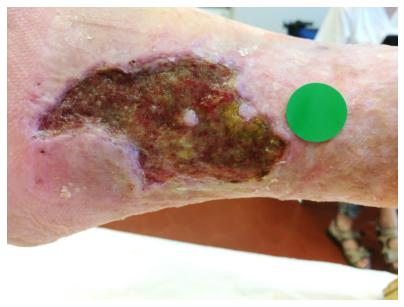

In [1]:
import cv2
import pylab as plt

# define the image filename
filename = 'image_marker.png'
# load the image using OpenCV library
img = cv2.imread(filename)
# convert the image to RGB fmt for the display
img = img[..., ::-1]

# define the plot figure
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))
canvas = ax.imshow(img)
_ = ax.axis('off')

The next step involves the estimation of the semantic segmentation mask, in which we can automatically identify the ROI of the wound, marker, and body.
To this purpose we will use the updated version of the model stored in the `deepskin` package.

Perform the semantic image segmentation...  [DONE] (7.679 sec)                  


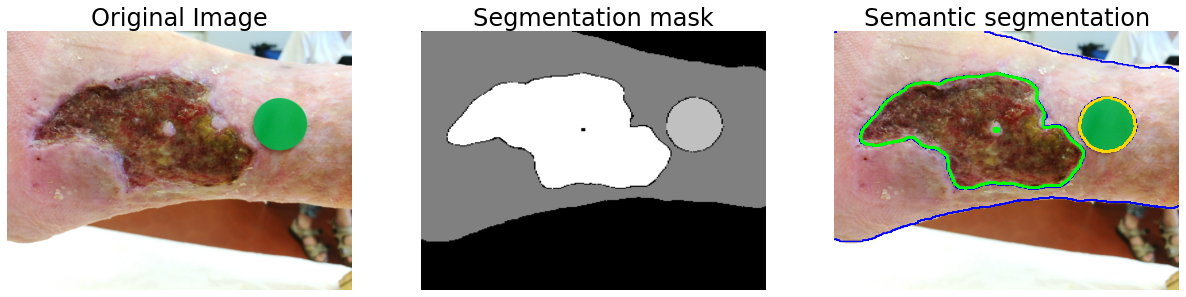

In [2]:
import cv2
import numpy as np
from deepskin import wound_segmentation

# get the wound segmentation mask
segmentation = wound_segmentation(
    img=img,
    tol=0.95,
    verbose=True,
)

bg_mask, body_mask, marker_mask, wound_mask = cv2.split(segmentation)
semantic_seg = np.where(body_mask != 0, 128, 0) | wound_mask | np.where(marker_mask != 0, 192, 0)

# display the results
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(21, 7))
ax1.imshow(img)
ax1.set_title('Original Image', fontsize=24)
_ = ax1.axis('off')
ax2.imshow(semantic_seg, cmap='gray')
ax2.set_title('Segmentation mask', fontsize=24)
_ = ax2.axis('off')
ax3.imshow(img)
ax3.contour(body_mask, colors='blue', linewidths=1)
ax3.contour(wound_mask, colors='lime', linewidths=2)
ax3.contour(marker_mask, colors='gold', linewidths=2)
ax3.set_title('Semantic segmentation', fontsize=24)
_ = ax3.axis('off')

Now we will show how to get the entire mesh triangulation using the Delaunay approach extended to cover also irregular shapes (with concavities).
This code is already implemented into the `shape_area` function: we manually re-implement it to show the intermediate results of its application on the real case image.

In [3]:
from deepskin.imgproc import extract_triangulation

# extract the shape contours
shape_cnt, _ = cv2.findContours(
    image=wound_mask, 
    mode=cv2.RETR_EXTERNAL, 
    method=cv2.CHAIN_APPROX_NONE
)
# filter only the largest one
shape_cnt = max(shape_cnt, key=len)
# remove useless dimensions
shape_cnt = np.squeeze(shape_cnt)
# convert it to a set for a faster computation
shape_cnt = set(map(tuple, shape_cnt))

# apply an erosion to the mask to get the
# contour points of an inner shape
kernel = cv2.getStructuringElement(
    shape=cv2.MORPH_ELLIPSE, 
    ksize=(3, 3)
)
eroded = cv2.erode(wound_mask, kernel, iterations=1)
# get the internal contours
internal_cnt, _ = cv2.findContours(
    image=eroded, 
    mode=cv2.RETR_EXTERNAL, 
    method=cv2.CHAIN_APPROX_NONE
)
# filter only the largest one
internal_cnt = max(internal_cnt, key=len)
# remove useless dimensions
internal_cnt = np.squeeze(internal_cnt)
# convert it to a set for a faster computation
internal_cnt = set(map(tuple, internal_cnt))

# update the list of points combining the two sets
internal_cnt.update(shape_cnt)
# convert the list to a numpy array
points = list(internal_cnt)

# get the internal triangles
internal_triangles = extract_triangulation(
    points=points,
    shape_cnt=shape_cnt,
    max_area=1000
)

For a correct visualization of the obtained triangles we can use the pylab plot

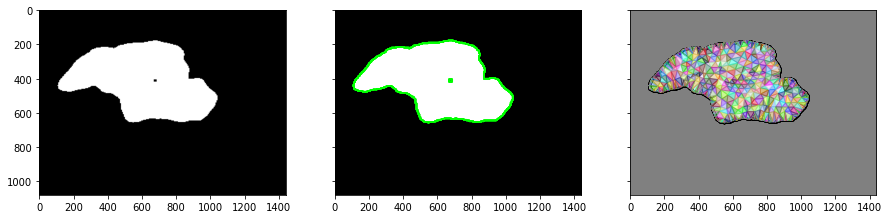

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharex=True, sharey=True)
ax1.imshow(wound_mask, cmap='gray')
ax2.imshow(eroded, cmap='gray')
ax2.contour(wound_mask, colors='lime')
ax3.imshow(wound_mask, cmap='gray', alpha=.5)
ax3.scatter(*zip(*points), c='k', s=1)
for t in internal_triangles:
    # get a random color
    color = np.random.choice(range(256), size=3) / 255
    # create a triangle patch
    patch = plt.Polygon(t, color=[*color, 0.5])
    # apply the patch to the figure
    ax3.add_patch(patch)

Now we need to correct our triangulation using the information stored in the depth map estimated on the image.
Since our implementation is independent by the model used for this step, we simply load a pre-defined depth map that in the current case was generated using the ZoeDepth model.

**⚠️ Note:** A depth map typically stores the information with a precision higher than the classical `uint8`, so pay attention to load it correctly, setting the `IMREAD_ANYDEPTH` keyword in the call.

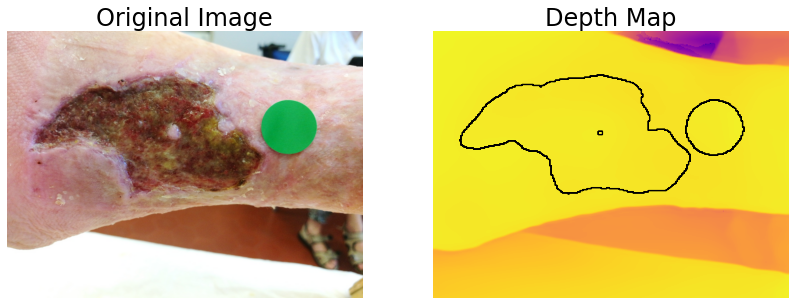

In [9]:
depth_map = cv2.imread('depth_map.png', cv2.IMREAD_ANYDEPTH)

# display the results
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))
ax1.imshow(img)
ax1.set_title('Original Image', fontsize=24)
_ = ax1.axis('off')
ax2.imshow(depth_map, cmap='plasma_r')
ax2.set_title('Depth Map', fontsize=24)
ax2.contour(wound_mask, colors='k', linewidths=1)
ax2.contour(marker_mask, colors='k', linewidths=1)
_ = ax2.axis('off')

The last step involves the association of the `z`-axis to each coordinate, considering both the vertices of triangles and contour shapes.

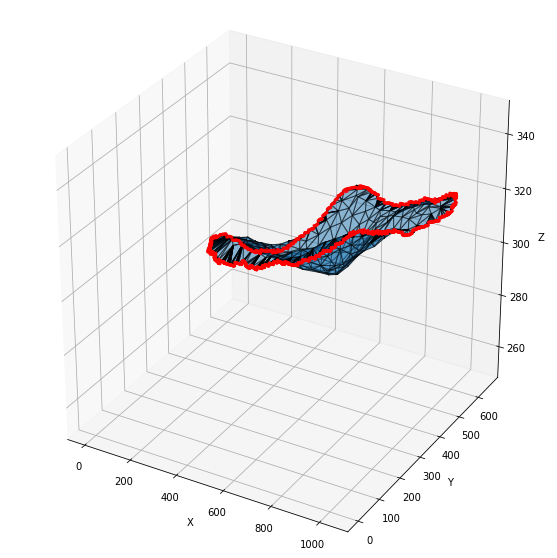

In [14]:
from deepskin.imgproc import _get_zcoord
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# add the z-axis to the contour point coordinates
extended_contours = [
    (x, y, _get_zcoord([(y, x)], depth_map))
    # (x, y, depth[y, x])
    for (x, y) in shape_cnt
]
# add the z-axis to the triangle vertices
extended_internal_triangles = [
    np.c_[t, _get_zcoord(t[:, ::-1], depth_map)]
    for t in internal_triangles
]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# create the triangulation mesh
mesh = Poly3DCollection(
    extended_internal_triangles, 
    alpha=0.5, 
    edgecolor='k'
)
ax.add_collection3d(mesh)

# plot the contour points
ax.scatter(
    *zip(*extended_contours), 
    color='r', 
    s=5
)

# set axes labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# fix the aspect ratio of the box
ax.set_box_aspect([1, 1, 1])
ax.set_zlim(250, 350)
plt.show()

All the code developed up to now are already inserted into the ready-to-use functions of the `deepskin` packages, so for a practical usage, we can directly evaluate the area of the wound lesione using the `shape_area` function stored into the `geometry` module.
Since the area is estimated according to the depth map provided, the value will be expressed in terms of arbitrary units.
A good approach is to compare the shape area with the area of another reference, like the marker one in this case.

In [16]:
from deepskin.geometry import shape_area

# compute the wound area in arbitrary
# units (aka the units of the depth map)
wound_area_au = shape_area(
    mask=wound_mask,
    depth=depth_map,
    max_area_triangles=100
)
# compute the marker area in arbitrary
# units (aka the units of the depth map)
marker_area_au = shape_area(
    mask=marker_mask,
    depth=depth_map,
    max_area_triangles=100
)

print(f'Wound Area (au): {wound_area_au:.3f}')
print(f'Marker Area (au): {marker_area_au:.3f}')

Wound Area (au): 280282.935
Marker Area (au): 43200.295


Knowing the exact area of the marker, we can simply adjust the score moving from arbitrary units to the classical $cm^2$ applying a simple proportion

In [20]:
# convert the arbitrary units to cm^2 knowing the
# area of the marker (pi in the current case)

# wound_au : x = marker_au : 3.14
wound_area_cm = (np.pi / marker_area_au) * wound_area_au

print(f'Wound Area (cm^2): {wound_area_cm:.3f}')

Wound Area (cm^2): 20.383
